In [1]:
import os
home = os.environ['HOME']
run_path = os.path.join(home, 'far/farMe/close/test_polytropic')

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import pyphare
import pyphare.pharesee as phc
from pyphare.pharesee.run import Run

In [4]:
run  = Run(run_path)
L = 40
k = 2*np.pi/L

In [5]:
from pyphare.pharesee.hierarchy.fromh5 import get_times_from_h5
file = os.path.join(run_path, "ions_charge_density.h5")
times = get_times_from_h5(file)  # = np.arange(0, 41, 2)

In [6]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

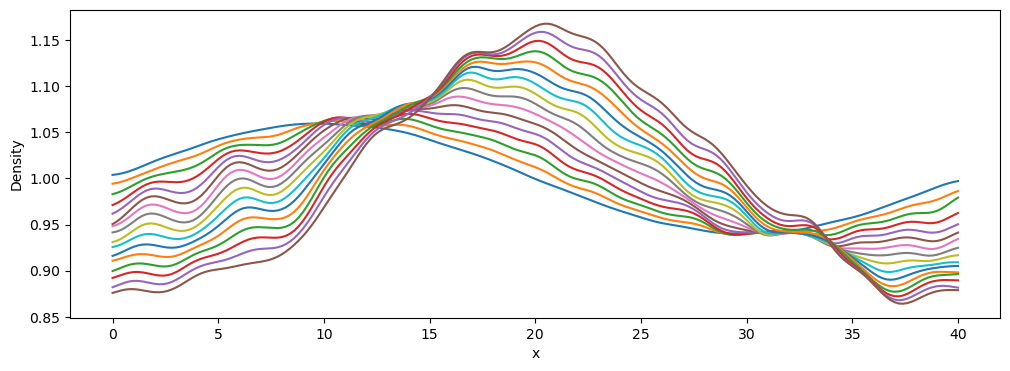

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))

for i, time in enumerate(times[::1]):
    N = run.GetNi(time)
    n = phc.filters.gaussian(N, sigma=4)
    n.plot(qty='value', ax=ax, ls='solid', lw=2.0, color=colors[i%10], ylabel='Density')

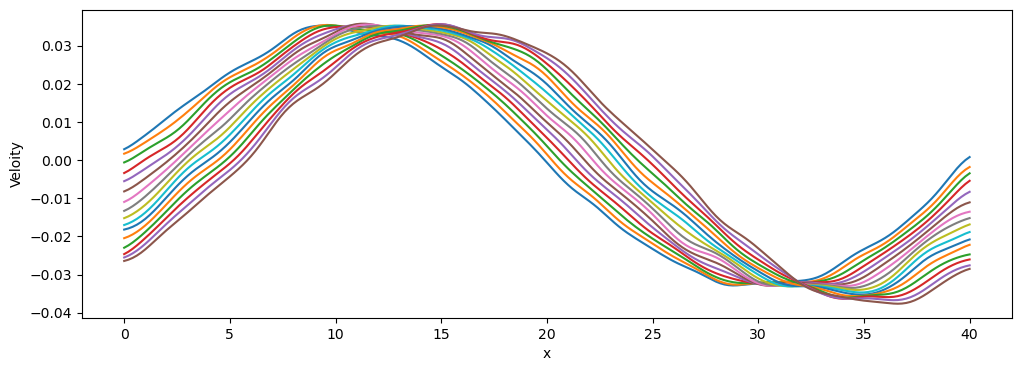

In [23]:
fig, ax = plt.subplots(figsize=(12, 4))

for i, time in enumerate(times[::1]):
    V = run.GetVi(time)
    v = phc.filters.gaussian(V, sigma=4)
    v.plot(qty='x', ax=ax, ls='solid', lw=2.0, color=colors[i%10], ylabel='Veloity')

In [8]:
from scipy.optimize import curve_fit
def sine_func(x, A, B, C):
    return A * np.sin(k * x + B) + C
def lin_func(x, A, B):
    return A * x + B

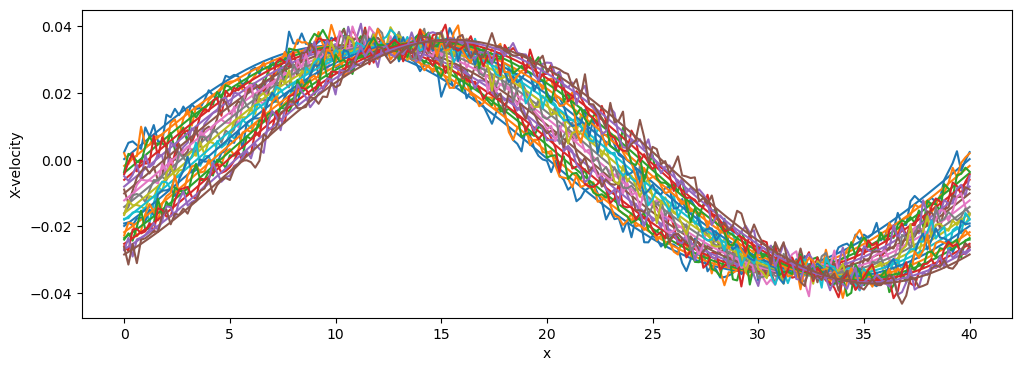

In [26]:
from pyphare.pharesee.hierarchy import uniformgrid as uniform

a1_far = np.zeros(times.shape)  # amplitude
f1_far = np.zeros(times.shape)  # phase

fig, ax = plt.subplots(figsize=(12, 4))

for i, tim in enumerate(times[::]):
    N = run.GetNi(tim, all_primal=False)
    n = N.finest()
    n_grid = n
    ghost_nb = n_grid.ghosts_nbr[0]
    x_ = v_grid.x[ghost_nb:-ghost_nb]

    V = run.GetVi(tim, all_primal=False)
    v = V.finest()
    v_grid = v['x']

    ghost_nb = v_grid.ghosts_nbr[0]
    x_ = v_grid.x[ghost_nb:-ghost_nb]
    w_ = np.asarray(v_grid[ghost_nb:-ghost_nb])

    params, covariance = curve_fit(sine_func, x_, w_, p0=[0.02, 0.0, 0.0])

    a1_far[i] = np.fabs(params[0])
    f1_far[i] = np.fabs(params[1])
    v.plot(qty='x', ax=ax, ls='solid', lw=2.0, color=colors[i%10], ylabel='X-velocity')
    ax.plot(x_, sine_func(x_, *params))

In [17]:
params, covariance = curve_fit(lin_func, times, f1_far, p0=[0.0125, 0.0])

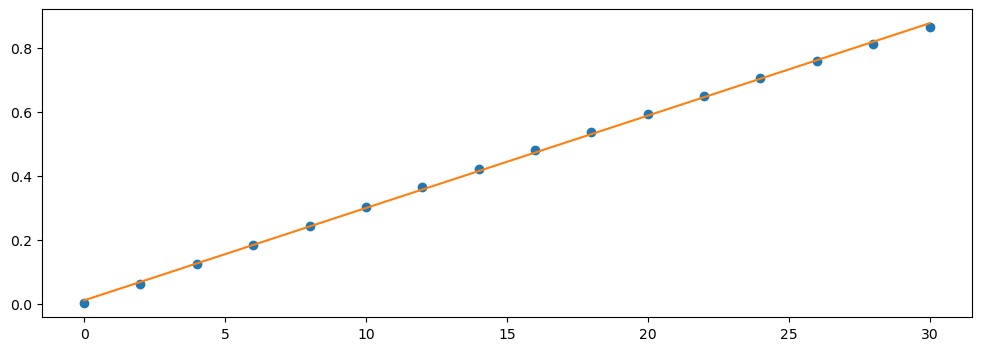

In [18]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(times, f1_far, lw=0, marker='o')
ax.plot(times, lin_func(times, *params))

In [19]:
gamma_e, gamma_i = 1, 3
Te, Ti = 0.1, 0.01
cs = np.sqrt(gamma_e*Te+gamma_i*Ti)

vphi_num = params[0]/k
vphi_AI = cs

In [20]:
vphi_num

np.float64(0.18384719220787218)

In [21]:
vphi_AI

np.float64(0.36055512754639896)

In [ ]:
# a1_far

In [ ]:
np.fabs(vphi_AI-vphi_num)/vphi_AI

In [ ]:
assert((np.fabs(vphi_AI-vphi_num)/vphi_AI) < 0.05)